![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

W zeszycie przedstawiono przykład obliczeniowy do testu dopasowania Kołmogorowa

In [1]:
import numpy as np
import scipy as sp
import scipy.stats as st
import pandas as pd
import matplotlib.pyplot as plt

Import danych i zamiana na numpy array, zmiana kształtu tablicy (żeby ułatwić sortowanie)

In [2]:
x = pd.read_csv("ks_data.csv").values

N = len(x) # wielkość próby
x = x.reshape(N,)

Wykonanie histogramu próby

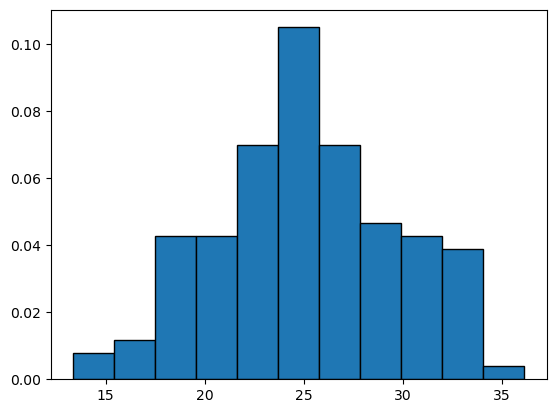

In [3]:
plt.hist(x,density=True,bins = int(np.sqrt(N)),edgecolor="black")
pass

**Utworzenie rozkadu teoretycznego**

Tu tworzony jest obiekt rozkładu normalnego, ponieważ testowana jest hipoteza, ze próba pochodzi z populacji generalnej o rozkładzie normalnym. W tym celu dokonuje się estymacji wymaganych parametrów na podsatwie próby.

In [4]:
m = st.tmean(x)
s = st.tstd(x)

rozkladNormalny = st.norm(m,s)

**Posortowanie otrzymanej próby rosnąco (xs), a anstępnie określenie wartości dystrybuanty rozkłądu teoretyznego (F) i dystrybuanty z próby.**

In [5]:
xs = np.sort(x) #sortowanie próby
F = rozkladNormalny.cdf(xs) # dystrybuanta rozkładu teoretycznego

Fni = np.fromiter(range(1,N+1),dtype=int)/N # dystrybuanta empiryczna (z próby)

**Wykres obu dystrybuant**

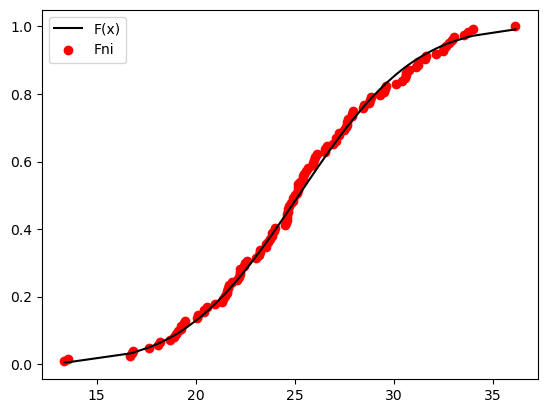

In [6]:
plt.plot(xs,F,color="black")
plt.scatter(xs,Fni,color="red")
plt.legend(["F(x)","Fni"])
pass

**Przeprowadzenie testu Kołmogorowa**

In [7]:
rozkladKolmogorowaSmirnowa = st.kstwobign() # utworzenie instancji obiektu reprezentującego rozkald KS

Dn = max(np.abs(F-Fni)) # obliczenie statystyki testowej - maksymalnej różnicy między dystrybuantami
stTest = np.sqrt(N)*Dn
pvalue = 1-rozkladKolmogorowaSmirnowa.cdf(stTest) # obliczenie p-wartości

print("Statystyka testowa Dn = {}; pvalue = {}".format(stTest,pvalue))

Statystyka testowa Dn = 0.4707669956191572; pvalue = 0.9796437747639198


P-wartość jest duża więc brak jest podstaw do odrzucenia hipotezy zerowej mówiącej o równości dystrybuant. Można uznać, że próba pochodzi z rokładu normalnego.

**Przeprowadzenie testu przy pomocy funkcji z modułu scipy.stats**

In [8]:
st.kstest(x,rozkladNormalny.cdf)

KstestResult(statistic=0.04227612421620808, pvalue=0.9729200551025323)